In [1]:
import sklearn
print(sklearn.__version__)

1.8.0


In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
print(df.shape)
print(df.head())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

In [10]:
df['label_num'] = df['label'].map({'ham':0,'spam':1})

In [11]:
X = df['message']
y = df['label_num']

In [12]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [14]:
vectorizer = TfidfVectorizer(stop_words = 'english',max_features = 5000)
X_Train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [15]:
model = MultinomialNB()
model.fit(X_Train_tfidf,y_train)
y_pred = model.predict(X_test_tfidf)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9820627802690582

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[965   1]
 [ 19 130]]


In [26]:
def predict_message(message):
    transformed = vectorizer.transform([message])
    prediction = model.predict(transformed)[0]
    return "SPAM" if prediction == 1 else "HAM "

# Test it!
msg = input("Enter the msg to predict:");
predict_message(msg)

Enter the msg to predict: Hi ! Congrates on clearing this Hr round ! and you are supposed to be on time on 23rd aug


'HAM '

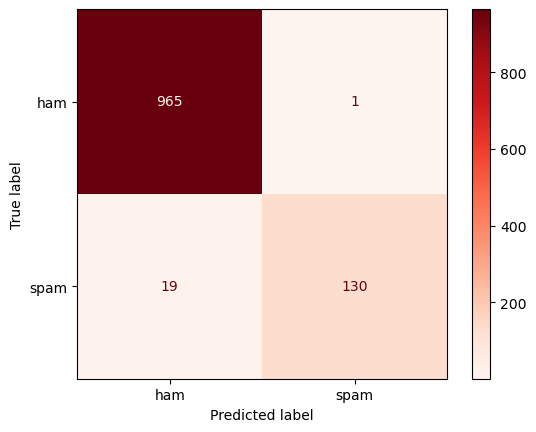

In [24]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])

disp.plot(cmap=plt.cm.Reds)
plt.show()